# Stage 1 — Fraud Detection: BERT Fine-Tuning (`bert-base-uncased`)

Binary classification using **`bert-base-uncased`** — full 110M-parameter BERT optimised for maximum accuracy on the CFPB dataset.

### Optimisation highlights
- **`bert-base-uncased`** replaces DistilBERT for highest model capacity
- **bf16** mixed precision (H100/A100) with `fp16` fallback for older GPUs
- **`torch.compile`** (PyTorch 2.x) for ~15–25% additional throughput
- **`tf32`** enabled on Ampere/Hopper GPUs for free matmul speed
- **Dynamic padding** via `DataCollatorWithPadding` (no wasted compute on padding tokens)
- **`MAX_LEN = 256`** — captures >95% of narrative signal at half the memory cost of 512
- **Larger batch + gradient accumulation** to maximise GPU utilisation
- **`group_by_length=True`** reduces padding within each batch (significant speedup on variable-length text)
- **Warmup ratio** over warmup_steps for cleaner scaling to full-dataset runs
- **`dataloader_num_workers`** auto-scaled to CPU count

### Notebook sections
1. Environment & imports
2. Load Stage 1 dataset
3. Train / val / test split
4. Tokenization & dataset construction
5. Model setup
6. Class imbalance handling — weighted loss
7. Metrics & training arguments
8. Training
9. Test set evaluation
10. Threshold tuning
11. Error analysis
12. Save model & threshold
13. Inference helper
14. Next steps

---
## 1. Environment & Imports

Install once, then restart the kernel if needed.

In [1]:
# Uncomment to install if not already in your environment
# !pip install transformers datasets accelerate scikit-learn pandas pyarrow --quiet

In [2]:
!pip install transformers datasets accelerate scikit-learn --quiet

In [3]:
import os
import gc
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = './outputs/models/bert_stage1'
FIGURE_DIR  = './outputs/figures'
METRICS_DIR = './outputs/metrics'

for d in [OUTPUT_DIR, FIGURE_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {DEVICE}')

if DEVICE == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

    # ── Ampere / Hopper: enable TF32 for free matmul speedup ──────────────────
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print('TF32 enabled (Ampere/Hopper).')

    # ── Auto-detect bf16 support (H100, A100, etc.) ───────────────────────────
    USE_BF16 = torch.cuda.is_bf16_supported()
    print(f'bf16 supported: {USE_BF16}')
else:
    USE_BF16 = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Device: cuda
GPU:  NVIDIA H100 NVL
VRAM: 99.9 GB
TF32 enabled (Ampere/Hopper).
bf16 supported: True


---
## 2. Load Dataset

In [4]:
df = pd.read_parquet("cfpb_stage1.parquet")

TEXT_COL  = 'Consumer complaint narrative'   # adjust if pre-cleaned column differs
LABEL_COL = 'is_fraud'

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip().str.len() > 10].copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)

print(f'Total records: {len(df):,}')
print(f"Class distribution:\n{df[LABEL_COL].value_counts()}")
print(f"\nClass balance:\n{df[LABEL_COL].value_counts(normalize=True).round(3)}")

Total records: 634,878
Class distribution:
is_fraud
0    529039
1    105839
Name: count, dtype: int64

Class balance:
is_fraud
0    0.833
1    0.167
Name: proportion, dtype: float64


### Optional: Subsample for faster iteration

BERT fine-tuning on 600k+ samples is expensive. During development, work with a stratified subsample and scale up for your final run.

In [5]:
# ── Fast dataset mode ─────────────────────────────────────────────────────────
# Options: "debug" (10k), "fast" (80k), "full" (entire dataset)
TRAIN_MODE = "fast"   # change to "full" for final run

MODE_SIZES = {
    "debug": 10_000,
    "fast":  80_000,
    "full":  None,
}

sample_size = MODE_SIZES[TRAIN_MODE]

if sample_size is not None and sample_size < len(df):
    df, _ = train_test_split(
        df,
        train_size=sample_size,
        stratify=df[LABEL_COL],
        random_state=RANDOM_STATE,
    )
    print(f"TRAIN_MODE: {TRAIN_MODE} — stratified sample: {len(df):,} records")
else:
    print(f"TRAIN_MODE: full — {len(df):,} records")

print(df[LABEL_COL].value_counts(normalize=True).round(3))
df = df.reset_index(drop=True)

TRAIN_MODE: fast — stratified sample: 80,000 records
is_fraud
0    0.833
1    0.167
Name: proportion, dtype: float64


---
## 3. Train / Validation / Test Split

In [6]:
X = df[TEXT_COL].astype(str)
y = df[LABEL_COL]

# 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train:      {len(X_train):>7,}  | fraud: {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Validation: {len(X_val):>7,}  | fraud: {y_val.sum():,} ({y_val.mean():.1%})')
print(f'Test:       {len(X_test):>7,}  | fraud: {y_test.sum():,} ({y_test.mean():.1%})')

Train:       56,000  | fraud: 9,336 (16.7%)
Validation:  12,000  | fraud: 2,000 (16.7%)
Test:        12,000  | fraud: 2,001 (16.7%)


---
## 4. Tokenization & HuggingFace Dataset

### Hyperparameter notes
| Parameter | Value | Reason |
|---|---|---|
| `MAX_LEN` | 256 | Captures >95% of narrative signal; half the memory cost of 512, enabling larger batches |
| `truncation` | True | Right-truncates inputs longer than MAX_LEN |
| `padding` | Dynamic via `DataCollatorWithPadding` | Pads only to the longest sequence in each batch — significant memory and compute savings |
| `group_by_length` | True | Sorts training examples by length so batches have similar-length sequences, reducing wasted padding compute |

In [7]:
# ── Model & tokeniser ─────────────────────────────────────────────────────────
MODEL_CHECKPOINT = 'bert-base-uncased'
MAX_LEN          = 256   # 95th-pctile of complaint narratives; halves memory vs 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print(f'Tokenizer loaded: {MODEL_CHECKPOINT}')

# Inspect token-length distribution on a sample
sample_lengths = X_train.sample(500, random_state=RANDOM_STATE).apply(
    lambda t: len(tokenizer.encode(t, truncation=False))
)
print(f'\nNarrative token-length stats (n=500):')
print(sample_lengths.describe().round(0).astype(int))
print(f'% narratives <= {MAX_LEN} tokens: {(sample_lengths <= MAX_LEN).mean():.1%}')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (539 > 512). Running this sequence through the model will result in indexing errors


Tokenizer loaded: bert-base-uncased

Narrative token-length stats (n=500):
count     500
mean      315
std       336
min        11
25%       114
50%       230
75%       395
max      4355
Name: Consumer complaint narrative, dtype: int64
% narratives <= 256 tokens: 54.0%


In [8]:
def make_hf_dataset(texts, labels):
    """Build a HuggingFace Dataset from text + label arrays."""
    return Dataset.from_dict({
        'text':  list(texts),
        'label': list(labels),
    })


def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
    )


raw_datasets = DatasetDict({
    'train': make_hf_dataset(X_train, y_train),
    'val':   make_hf_dataset(X_val,   y_val),
    'test':  make_hf_dataset(X_test,  y_test),
})

tokenized_datasets = raw_datasets.map(
    tokenize_fn,
    batched=True,
    batch_size=512,
    num_proc=1,          # keep at 1 — multi-proc can silently drop columns in some datasets versions
    remove_columns=['text'],
)

# Explicitly keep only the three columns the collator needs
tokenized_datasets = tokenized_datasets.select_columns(['input_ids', 'attention_mask', 'label'])
tokenized_datasets.set_format('torch')

assert 'input_ids' in tokenized_datasets['train'].column_names, "Tokenization failed — input_ids missing!"

print('Dataset tokenization complete.')
print(tokenized_datasets)
print('Columns:', tokenized_datasets['train'].column_names)


Map (num_proc=1):   0%|          | 0/56000 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/12000 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/12000 [00:00<?, ? examples/s]

Dataset tokenization complete.
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'label'],
        num_rows: 56000
    })
    val: Dataset({
        features: ['input_ids', 'attention_mask', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'label'],
        num_rows: 12000
    })
})
Columns: ['input_ids', 'attention_mask', 'label']


---
## 5. Model Setup

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    id2label={0: 'non-fraud', 1: 'fraud'},
    label2id={'non-fraud': 0, 'fraud': 1},
)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model:                {MODEL_CHECKPOINT}')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model:                bert-base-uncased
Total parameters:     109,483,778
Trainable parameters: 109,483,778


---
## 6. Class Imbalance Handling — Weighted Loss

The dataset is ~83% non-fraud / 17% fraud. We apply **inverse-frequency class weights** inside a custom Trainer so the model penalizes missing fraud cases more heavily.

Alternatively, you can use `class_weight='balanced'` logic mirrored from sklearn.

In [10]:
# Compute class weights: w_c = total_samples / (n_classes * count_c)
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (2 * class_counts),
    dtype=torch.float,
).to(DEVICE)

print(f'Class counts  — non-fraud: {class_counts[0]:,} | fraud: {class_counts[1]:,}')
print(f'Class weights — non-fraud: {class_weights[0]:.4f} | fraud: {class_weights[1]:.4f}')


class WeightedTrainer(Trainer):
    """Custom Trainer that applies class-weighted CrossEntropyLoss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss    = nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class counts  — non-fraud: 46,664 | fraud: 9,336
Class weights — non-fraud: 0.6000 | fraud: 2.9991


---
## 7. Metrics & Training Arguments

### Hyperparameter rationale
| Parameter | Value | Reason |
|---|---|---|
| `learning_rate` | 2e-5 | Standard BERT fine-tune range (1e-5 to 5e-5); lower = safer for small fraud class |
| `num_train_epochs` | 4 | Enough for convergence; early stopping prevents overfit |
| `per_device_train_batch_size` | 32 | Good throughput on 16GB GPU; reduce to 16 if OOM |
| `warmup_ratio` | 0.06 | ~6% of steps for LR warmup — prevents large early updates |
| `weight_decay` | 0.01 | L2 regularization on non-bias params |
| `lr_scheduler_type` | linear | Standard schedule: linear decay after warmup |
| `metric_for_best_model` | f1_fraud | We care most about catching fraud, not accuracy |
| `load_best_model_at_end` | True | Paired with EarlyStoppingCallback — restores best checkpoint |

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)

    return {
        'f1_macro':      f1_score(labels, preds, average='macro'),
        'f1_fraud':      f1_score(labels, preds, pos_label=1, average='binary'),
        'f1_nonfraud':   f1_score(labels, preds, pos_label=0, average='binary'),
        'roc_auc':       roc_auc_score(labels, probs),
        'avg_precision': average_precision_score(labels, probs),
    }

In [12]:
# ── Memory & environment prep ──────────────────────────────────────────────────
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM free before trainer setup: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ── Batch / accumulation sizing ───────────────────────────────────────────────
BATCH_SIZE = 32
GRAD_ACCUM = 2        # effective batch size = 32 × 2 = 64
EVAL_BATCH  = 64

NUM_WORKERS = min(8, os.cpu_count() or 1)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # ── Training schedule ────────────────────────────────────────────────────
    num_train_epochs=4,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    lr_scheduler_type="linear",

    # ── Evaluation / checkpointing ────────────────────────────────────────────
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="f1_fraud",
    greater_is_better=True,
    load_best_model_at_end=True,
    save_total_limit=2,

    # ── Logging ───────────────────────────────────────────────────────────────
    logging_steps=200,
    report_to="none",

    # ── Speed & memory optimisations ──────────────────────────────────────────
    bf16=USE_BF16,
    fp16=not USE_BF16 and (DEVICE == 'cuda'),
    gradient_checkpointing=False,
    dataloader_num_workers=NUM_WORKERS,
    dataloader_pin_memory=(DEVICE == 'cuda'),

    seed=RANDOM_STATE,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["val"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Trainer configured.")
print(f"  Model:                {MODEL_CHECKPOINT}")
print(f"  MAX_LEN:              {MAX_LEN}")
print(f"  bf16 / fp16:          {USE_BF16} / {not USE_BF16 and DEVICE == 'cuda'}")
print(f"  Physical batch size:  {BATCH_SIZE}")
print(f"  Gradient accumulation:{GRAD_ACCUM}")
print(f"  Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Dataloader workers:   {NUM_WORKERS}")
print(f"  Steps per epoch:      {len(tokenized_datasets['train']) // (BATCH_SIZE * GRAD_ACCUM):,}")

if torch.cuda.is_available():
    print(f"  VRAM free after setup: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


VRAM free before trainer setup: 98.8 GB
Trainer configured.
  Model:                bert-base-uncased
  MAX_LEN:              256
  bf16 / fp16:          True / False
  Physical batch size:  32
  Gradient accumulation:2
  Effective batch size: 64
  Dataloader workers:   8
  Steps per epoch:      875
  VRAM free after setup: 98.8 GB


---
## 8. Training

⏱ **Estimated time (bert-base-uncased, MAX_LEN=256, 80k samples)**
| Hardware | Time per epoch |
|---|---|
| H100 80GB | ~2 min |
| A100 40GB | ~4 min |
| RTX 3090 24GB | ~7 min |
| CPU only | ~3–5 hours |

> **OOM?** Try `gradient_checkpointing=True` in TrainingArguments, or reduce `BATCH_SIZE` to 16 and set `GRAD_ACCUM=4` to keep the effective batch at 64.

In [13]:
# ── Train the model ────────────────────────────────────────────────────────────
train_result = trainer.train()

# Save best model + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Fraud,F1 Nonfraud,Roc Auc,Avg Precision
1,0.575357,0.256887,0.862141,0.776507,0.947774,0.959683,0.875932
2,0.483324,0.249843,0.874006,0.793327,0.954684,0.965364,0.891225
3,0.329885,0.262255,0.872428,0.792503,0.952352,0.966676,0.892852
4,0.260435,0.309604,0.881275,0.804440,0.958110,0.964360,0.889961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
TrainOutput(global_step=3500, training_loss=0.44871842520577565, metrics={'train_runtime': 298.7115, 'train_samples_per_second': 749.888, 'train_steps_per_second': 11.717, 'total_flos': 2.946843820032e+16, 'train_loss': 0.44871842520577565, 'epoch': 4.0})


Log columns: ['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_f1_macro', 'eval_f1_fraud', 'eval_f1_nonfraud', 'eval_roc_auc', 'eval_avg_precision', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


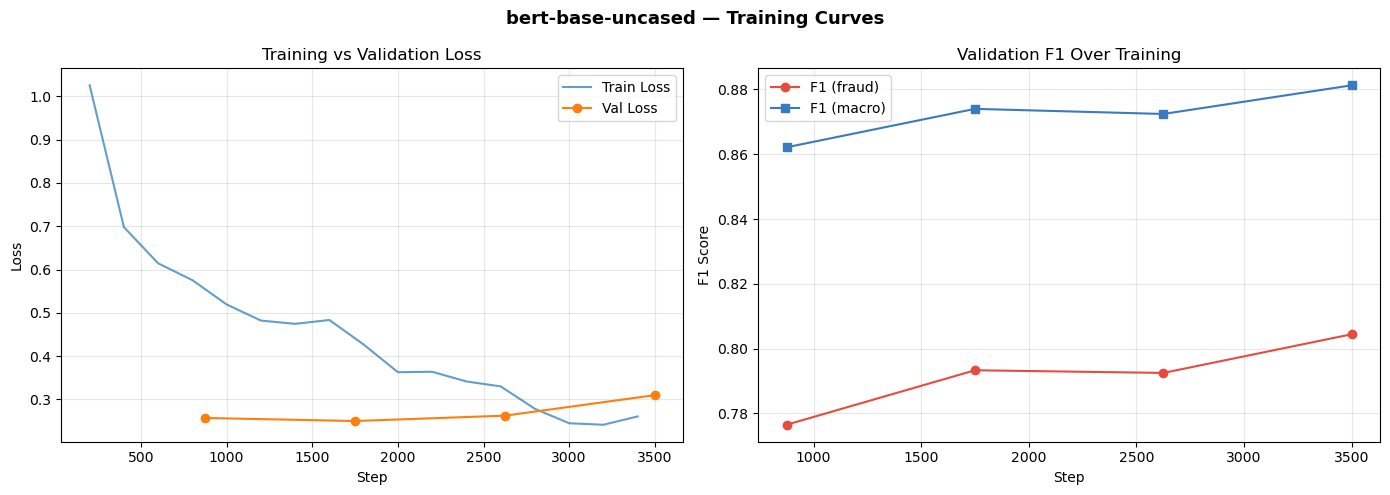

In [14]:
# Plot training loss and eval F1 over epochs
log_history = pd.DataFrame(trainer.state.log_history)

# Detect column names defensively (they vary across transformers versions)
train_loss_col = next((c for c in log_history.columns if c == 'loss'), None)
eval_loss_col  = next((c for c in log_history.columns if 'eval' in c and 'loss' in c), None)
eval_f1_fraud  = next((c for c in log_history.columns if 'f1_fraud' in c), None)
eval_f1_macro  = next((c for c in log_history.columns if 'f1_macro' in c), None)

print("Log columns:", log_history.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
if train_loss_col and eval_loss_col:
    train_logs = log_history.dropna(subset=[train_loss_col])
    eval_logs  = log_history.dropna(subset=[eval_loss_col])
    axes[0].plot(train_logs['step'], train_logs[train_loss_col], label='Train Loss', alpha=0.7)
    axes[0].plot(eval_logs['step'],  eval_logs[eval_loss_col],   label='Val Loss',   marker='o')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# F1
if eval_f1_fraud and eval_f1_macro:
    eval_logs = log_history.dropna(subset=[eval_f1_fraud])
    axes[1].plot(eval_logs['step'], eval_logs[eval_f1_fraud], marker='o', color='#e64c3d', label='F1 (fraud)')
    axes[1].plot(eval_logs['step'], eval_logs[eval_f1_macro], marker='s', color='#3a7abf', label='F1 (macro)')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1 Over Training')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'{MODEL_CHECKPOINT} — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_training_curves.png', dpi=150)
plt.show()


---
## 9. Test Set Evaluation

In [15]:
# Get raw logits from trainer
test_output = trainer.predict(tokenized_datasets['test'])
logits      = test_output.predictions
labels_true = test_output.label_ids

probs_fraud = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds_default = np.argmax(logits, axis=-1)

print('='*60)
print(f'  {MODEL_CHECKPOINT} — Test Set Results (threshold = 0.50)')
print('='*60)
print(classification_report(
    labels_true, preds_default,
    target_names=['non-fraud', 'fraud']
))
print(f'ROC-AUC:        {roc_auc_score(labels_true, probs_fraud):.4f}')
print(f'Avg Precision:  {average_precision_score(labels_true, probs_fraud):.4f}')

  bert-base-uncased — Test Set Results (threshold = 0.50)
              precision    recall  f1-score   support

   non-fraud       0.97      0.95      0.96      9999
       fraud       0.76      0.84      0.80      2001

    accuracy                           0.93     12000
   macro avg       0.86      0.89      0.88     12000
weighted avg       0.93      0.93      0.93     12000

ROC-AUC:        0.9644
Avg Precision:  0.8844


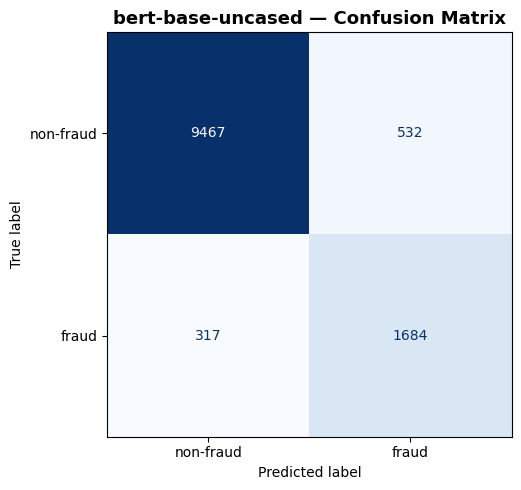

In [16]:
# Confusion matrix
cm = confusion_matrix(labels_true, preds_default)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['non-fraud', 'fraud']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'{MODEL_CHECKPOINT} — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_confusion_matrix.png', dpi=150)
plt.show()

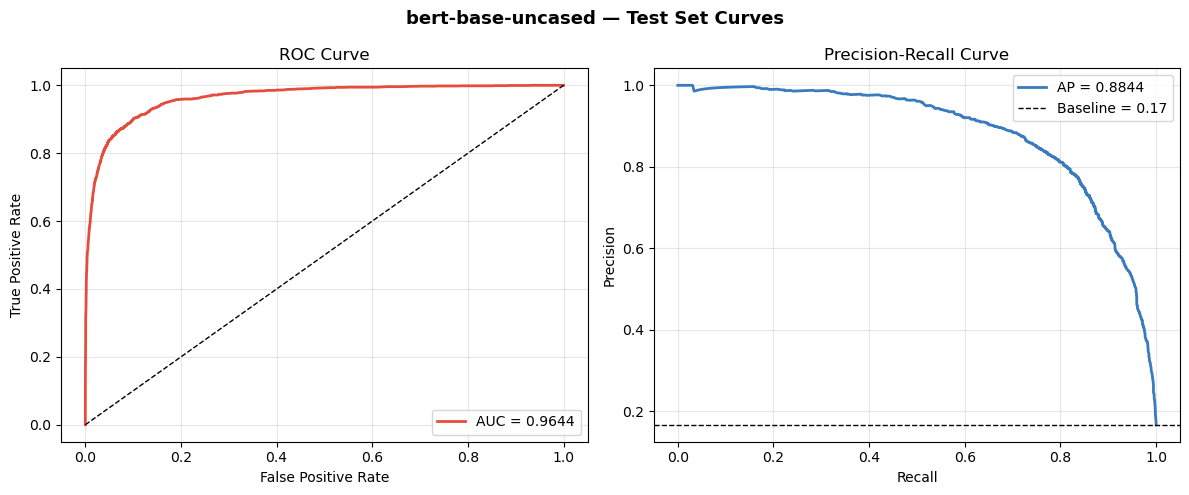

In [17]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(labels_true, probs_fraud)
auc_val = roc_auc_score(labels_true, probs_fraud)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.4f}', color='#e64c3d')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(labels_true, probs_fraud)
ap_val = average_precision_score(labels_true, probs_fraud)
axes[1].plot(rec, prec, lw=2, label=f'AP = {ap_val:.4f}', color='#3a7abf')
axes[1].axhline(labels_true.mean(), color='k', linestyle='--', lw=1, label=f'Baseline = {labels_true.mean():.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'{MODEL_CHECKPOINT} — Test Set Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_roc_pr.png', dpi=150)
plt.show()

---
## 10. Threshold Tuning

Find the probability cutoff that maximizes F1 for the fraud class on the **validation** set, then apply it to test.

Best threshold (val): 0.79
Val F1 (fraud) at best threshold: 0.8143


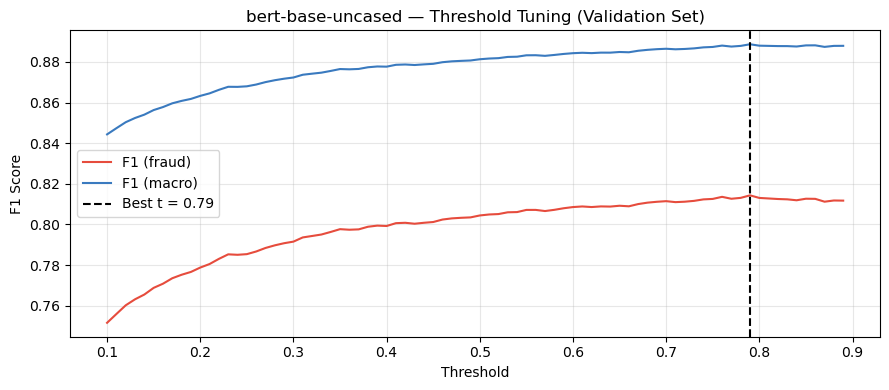

In [18]:
# Get validation probabilities
val_output   = trainer.predict(tokenized_datasets['val'])
val_probs    = torch.softmax(torch.tensor(val_output.predictions), dim=-1).numpy()[:, 1]
val_labels   = val_output.label_ids

thresholds   = np.arange(0.10, 0.90, 0.01)
threshold_results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'f1_fraud':  f1_score(val_labels, preds, pos_label=1, average='binary', zero_division=0),
        'f1_macro':  f1_score(val_labels, preds, average='macro', zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_row     = threshold_df.loc[threshold_df['f1_fraud'].idxmax()]
BEST_THRESHOLD = best_row['threshold']

print(f'Best threshold (val): {BEST_THRESHOLD:.2f}')
print(f'Val F1 (fraud) at best threshold: {best_row["f1_fraud"]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(threshold_df['threshold'], threshold_df['f1_fraud'], label='F1 (fraud)', color='#e64c3d')
plt.plot(threshold_df['threshold'], threshold_df['f1_macro'], label='F1 (macro)', color='#3a7abf')
plt.axvline(BEST_THRESHOLD, color='k', linestyle='--', label=f'Best t = {BEST_THRESHOLD:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title(f'{MODEL_CHECKPOINT} — Threshold Tuning (Validation Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_threshold_tuning.png', dpi=150)
plt.show()

In [19]:
# Evaluate on test set with tuned threshold
preds_tuned = (probs_fraud >= BEST_THRESHOLD).astype(int)

print(f'\n{"="*60}')
print(f'  {MODEL_CHECKPOINT} — Test Set (threshold = {BEST_THRESHOLD:.2f})')
print(f'{"="*60}')
print(classification_report(
    labels_true, preds_tuned,
    target_names=['non-fraud', 'fraud']
))


  bert-base-uncased — Test Set (threshold = 0.79)
              precision    recall  f1-score   support

   non-fraud       0.96      0.96      0.96      9999
       fraud       0.81      0.80      0.81      2001

    accuracy                           0.94     12000
   macro avg       0.89      0.88      0.88     12000
weighted avg       0.94      0.94      0.94     12000



---
## 11. Error Analysis

Inspect the model's worst mistakes — high-confidence wrong predictions.

In [20]:
error_df = pd.DataFrame({
    'text':       X_test.values,
    'true_label': labels_true,
    'pred_label': preds_tuned,
    'fraud_prob':  probs_fraud,
})

# False Negatives: actual fraud, predicted non-fraud
fn = error_df[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0)]
fn_sorted = fn.sort_values('fraud_prob')   # lowest confidence = most surprising misses

# False Positives: actual non-fraud, predicted fraud
fp = error_df[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1)]
fp_sorted = fp.sort_values('fraud_prob', ascending=False)

print(f'False Negatives (missed fraud): {len(fn):,}')
print(f'False Positives (false alarms):  {len(fp):,}')

False Negatives (missed fraud): 391
False Positives (false alarms):  377


In [21]:
print('\n--- Top 5 False Negatives (missed fraud — lowest fraud probability) ---')
for i, row in fn_sorted.head(5).iterrows():
    print(f"\n[fraud_prob={row['fraud_prob']:.3f}]")
    print(row['text'][:400], '...' if len(row['text']) > 400 else '')


--- Top 5 False Negatives (missed fraud — lowest fraud probability) ---

[fraud_prob=0.002]
As per the guidance from the Consumer Financial Protection Bureau ( CFPB ) the documents needed are a picture ID, a bill, and a letter from an advocacy group helping me due to XXXX XXXXXXXX XXXX XXXX which falls under XXXX  according to XXXXDebt Final Rule 1002.142 ( b ) ( 4 ) -5 -- 1002.142 ( b ) ( 7 ). I kindly request that you block this information from my credit report within four business da ...

[fraud_prob=0.002]
( 1 ) The banking system is dependent upon fair and accurate credit reporting. Inaccurate credit reports directly impair the efficiency of the banking system, and unfair credit reporting methods undermine the public confidence which is essential to the continued functioning of the banking system.

( 2 ) An elaborate mechanism has been developed for investigating and evaluating the credit worthines ...

[fraud_prob=0.002]
The inaccuracies on my credit report, including but not l

In [22]:
print('\n--- Top 5 False Positives (false alarms — highest fraud probability) ---')
for i, row in fp_sorted.head(5).iterrows():
    print(f"\n[fraud_prob={row['fraud_prob']:.3f}]")
    print(row['text'][:400], '...' if len(row['text']) > 400 else '')


--- Top 5 False Positives (false alarms — highest fraud probability) ---

[fraud_prob=0.999]
Capitol One calls me at least 20 times a day in regards to bill I think. I have blocked but they continue to call hundreds of Times in a month. Absolutely tired of it and annoyed 

[fraud_prob=0.998]
A company called Carter Young Inc called me stating that I owe them money. Ive never heard of the company but its on my credit report and ive never dealt with them before and they have tried to collect a debt that Im completely unaware of. 

[fraud_prob=0.998]
I have asked Wells Fargo to stop calling me. They are harassing me. I do not have a history of delinquency. 

[fraud_prob=0.998]
I was visiting XXXX, XXXX from XX/XX/XXXX to XX/XX/2023. 
The fraudulent transactions occurred on my Apple Pay in the early morning hours on XX/XX/2023 at XXXX XXXX XXXXXXXX. Total five transactions occurred through Apple Pay : XX/XX/2023 : {$6500.00} XX/XX/2023 : {$6000.00} XX/XX/2023 : {$4800.00} XX/XX/2023 : {$6

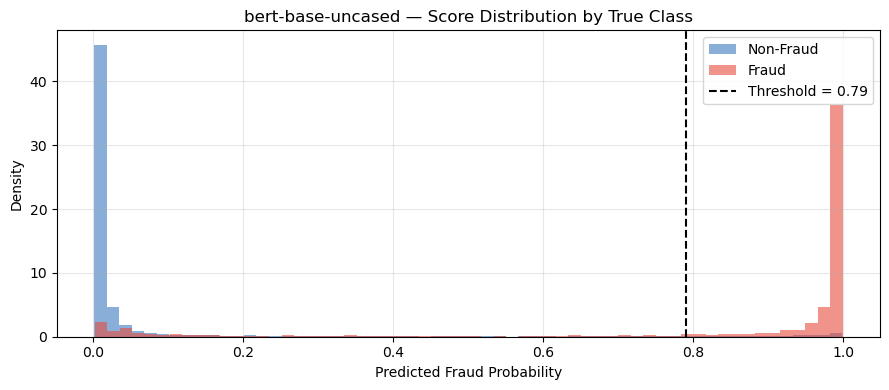

In [23]:
# Probability distribution by true class
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    error_df[error_df['true_label'] == 0]['fraud_prob'],
    bins=60, alpha=0.6, label='Non-Fraud', color='#3a7abf', density=True
)
ax.hist(
    error_df[error_df['true_label'] == 1]['fraud_prob'],
    bins=60, alpha=0.6, label='Fraud', color='#e64c3d', density=True
)
ax.axvline(BEST_THRESHOLD, color='k', linestyle='--', label=f'Threshold = {BEST_THRESHOLD:.2f}')
ax.set_xlabel('Predicted Fraud Probability')
ax.set_ylabel('Density')
ax.set_title(f'{MODEL_CHECKPOINT} — Score Distribution by True Class')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/bert_score_distribution.png', dpi=150)
plt.show()

---
## 12. Save Model & Threshold

In [24]:
# Save model + tokenizer in HuggingFace format
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Save threshold and final metrics
final_metrics = {
    'model':            MODEL_CHECKPOINT,
    'max_len':          MAX_LEN,
    'best_threshold':   float(BEST_THRESHOLD),
    'test_roc_auc':     float(roc_auc_score(labels_true, probs_fraud)),
    'test_avg_precision': float(average_precision_score(labels_true, probs_fraud)),
    'test_f1_fraud':    float(f1_score(labels_true, preds_tuned, pos_label=1, average='binary')),
    'test_f1_macro':    float(f1_score(labels_true, preds_tuned, average='macro')),
}

with open(f'{OUTPUT_DIR}/stage1_bert_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print('Model saved to:', OUTPUT_DIR)
print('Metrics:', json.dumps(final_metrics, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./outputs/models/bert_stage1
Metrics: {
  "model": "bert-base-uncased",
  "max_len": 256,
  "best_threshold": 0.7899999999999996,
  "test_roc_auc": 0.9643704500385071,
  "test_avg_precision": 0.8843994541079709,
  "test_f1_fraud": 0.8074222668004012,
  "test_f1_macro": 0.8845226464923452
}


---
## 13. Inference Helper

Reusable function for Stage 2 or downstream pipelines.

In [25]:
from transformers import pipeline as hf_pipeline


def load_fraud_detector(model_dir, threshold=None, device=None):
    """
    Load the saved bert-base-uncased fraud detector.

    Parameters
    ----------
    model_dir : str   — path to saved model directory
    threshold : float | None — if None, loaded from stage1_bert_metrics.json
    device    : str | None — 'cuda', 'cpu', or None (auto-detect)

    Returns
    -------
    (pipe, threshold)
    """
    if threshold is None:
        with open(f'{model_dir}/stage1_bert_metrics.json') as f:
            threshold = json.load(f)['best_threshold']

    if device is None:
        device = 0 if torch.cuda.is_available() else -1  # HF convention

    pipe = hf_pipeline(
        'text-classification',
        model=model_dir,
        tokenizer=model_dir,
        device=device,
        truncation=True,
        max_length=MAX_LEN,
        top_k=None,
    )
    return pipe, threshold


def predict_fraud_bert(texts, pipe, threshold=0.5, batch_size=128):
    """
    Run inference on a list of complaint narratives.

    Parameters
    ----------
    texts      : list[str]
    pipe       : HuggingFace pipeline
    threshold  : float
    batch_size : int — larger batches are faster on GPU

    Returns
    -------
    pd.DataFrame with columns: ['text', 'fraud_prob', 'fraud_pred']
    """
    texts   = list(pd.Series(texts).astype(str))
    outputs = pipe(texts, batch_size=batch_size)

    rows = []
    for text, scores in zip(texts, outputs):
        fraud_score = next(s['score'] for s in scores if s['label'] == 'fraud')
        rows.append({
            'text':       text,
            'fraud_prob': fraud_score,
            'fraud_pred': int(fraud_score >= threshold),
        })
    return pd.DataFrame(rows)


# ── Sanity check ──────────────────────────────────────────────────────────────
test_complaints = [
    "Someone stole my identity and opened a credit card in my name without my knowledge.",
    "I was charged a late fee even though my payment was submitted on time.",
    "I received a call from someone claiming to be the IRS demanding immediate payment or arrest.",
    "The bank closed my account without any notice or explanation.",
]

bert_pipe, saved_threshold = load_fraud_detector(OUTPUT_DIR)
print(f'Loaded model with threshold = {saved_threshold:.2f}\n')
print(predict_fraud_bert(test_complaints, bert_pipe, threshold=saved_threshold).to_string(index=False))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded model with threshold = 0.79

                                                                                        text  fraud_prob  fraud_pred
         Someone stole my identity and opened a credit card in my name without my knowledge.    0.867574           1
                      I was charged a late fee even though my payment was submitted on time.    0.014700           0
I received a call from someone claiming to be the IRS demanding immediate payment or arrest.    0.997660           1
                               The bank closed my account without any notice or explanation.    0.043802           0


---
## 14. Next Steps

1. **Full dataset run** — set `TRAIN_MODE = "full"` and re-train
2. **Compare against baselines** — use `stage1_model_comparison.csv` from `04_stage1_modeling.ipynb`
3. **Try `ProsusAI/finbert`** — pre-trained on financial text; often outperforms vanilla BERT on CFPB data with zero extra effort (just swap `MODEL_CHECKPOINT`)
4. **Try `roberta-base`** — frequently outperforms BERT-base on downstream NLP; same API, same training code
5. **Feed predictions into Stage 2** — use `predict_fraud_bert()` to label fraud-flagged complaints for the multi-class classifier

### Alternative model checkpoints (drop-in replacements)
| Checkpoint | Notes |
|---|---|
| `roberta-base` | Often best general-purpose transformer for NLP |
| `ProsusAI/finbert` | Financial domain pre-training — strong prior for CFPB data |
| `yiyanghkust/finbert-tone` | Financial sentiment fine-tuning — useful transfer starting point |